In [1]:
from __future__ import print_function
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from astropy.io import fits
from glob import glob
from astropy.time import Time
from astropy import coordinates as coords
from astropy import units as u
from astropy import constants as const
from astropy import convolution as conv
from astropy.table import Table, Column
import scipy.interpolate as scinterp
import time
start = time.time()

import wdatmos
import spec_plot_tools as spt
import cal_params as cp
import plot_spec as ps
print(os.getcwd())



no file_setting specificied


/Users/BenKaiser/Desktop/radial_velocity_calculations


In [2]:
target_dir= '/Users/BenKaiser/Desktop/files_for_Dufour/'
M0703_file='ravg_fwctb.GaiaJ1644m0449_20190703_400m2.fits'
M0729_file='ravg_fwctb.GaiaJ1644m0449_20190729_400m1.fits'
M0825_file='ravg_fwctb.GaiaJ1644m0449_20190825_400m2.fits'
model_spec_file='J1644_fit_flambda.dms'
#target_spec_file= glob(target_dir+target_spec_file)
#model_spec_file= glob(target_dir+model_spec_file)
print(model_spec_file)

J1644_fit_flambda.dms


In [3]:
os.chdir(target_dir)

In [4]:
print(os.getcwd())

/Users/BenKaiser/Desktop/files_for_Dufour


In [5]:
M0703_spec, M0703_header, M0703_noise= spt.retrieve_spec(M0703_file)
M0729_spec, M0729_header, M0729_noise= spt.retrieve_spec(M0729_file)
M0825_spec, M0825_header, M0825_noise= spt.retrieve_spec(M0825_file)
model_spec= spt.retrieve_model_spec(model_spec_file)

Ok we now have all of those spectra, so we just need to do the measurements and stuff now

In [6]:
li_bounds= [6650,6770] #approximately even on either side in air...
cont_width=40

So I guess I should run the function on them now?


=====



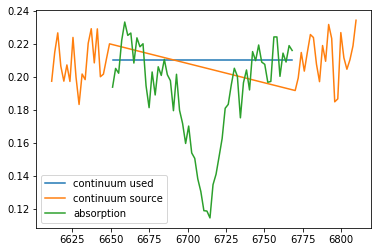

abs_energy/abs_energy_noise: 118.723562111
abs_energy 22.6596510205 +/- 0.19086060608
energy_dif 2.31710062601 +/- 0.539465413045
EW: 11.0347460186 +/- 2.56910025915


(11.034746018566997, 2.569100259148879)

In [7]:
spt.get_ew(M0703_file, li_bounds, plot_all=True, cont_width=cont_width)


=====



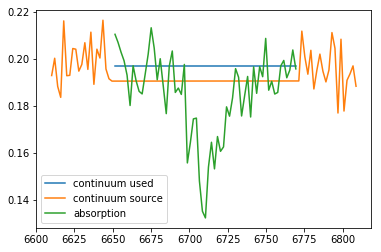

abs_energy/abs_energy_noise: 161.929124731
abs_energy 22.1793449148 +/- 0.136969460877
energy_dif 1.44929169281 +/- 0.492424702927
EW: 7.34918172901 +/- 2.49702571789


(7.3491817290118036, 2.4970257178851605)

In [8]:
spt.get_ew(M0729_file, li_bounds, plot_all=True, cont_width=cont_width)


=====



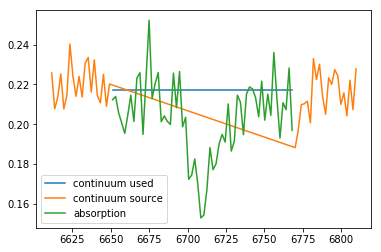

abs_energy/abs_energy_noise: 137.534734512
abs_energy 24.1769033964 +/- 0.175787618177
energy_dif 1.66045360035 +/- 0.550399905869
EW: 7.64367538897 +/- 2.53369212707


(7.6436753889728983, 2.5336921270686465)

In [9]:
spt.get_ew(M0825_file, li_bounds, plot_all=True, cont_width=cont_width)

In [10]:
spt.get_ew(M0703_file, li_bounds, plot_all=False, cont_width=cont_width)
spt.get_ew(M0729_file, li_bounds, plot_all=False, cont_width=cont_width)
spt.get_ew(M0825_file, li_bounds, plot_all=False, cont_width=cont_width)


=====

abs_energy/abs_energy_noise: 118.723562111
abs_energy 22.6596510205 +/- 0.19086060608
energy_dif 2.31710062601 +/- 0.539465413045
EW: 11.0347460186 +/- 2.56910025915

=====

abs_energy/abs_energy_noise: 161.929124731
abs_energy 22.1793449148 +/- 0.136969460877
energy_dif 1.44929169281 +/- 0.492424702927
EW: 7.34918172901 +/- 2.49702571789

=====

abs_energy/abs_energy_noise: 137.534734512
abs_energy 24.1769033964 +/- 0.175787618177
energy_dif 1.66045360035 +/- 0.550399905869
EW: 7.64367538897 +/- 2.53369212707


(7.6436753889728983, 2.5336921270686465)

In [11]:
spt.get_ew(M0703_file, li_bounds, plot_all=False)
spt.get_ew(M0729_file, li_bounds, plot_all=False)
spt.get_ew(M0825_file, li_bounds, plot_all=False)


=====

abs_energy/abs_energy_noise: 118.723562111
abs_energy 22.6596510205 +/- 0.19086060608
energy_dif 2.40009650715 +/- 0.732244342995
EW: 11.3921426979 +/- 3.47562359274

=====

abs_energy/abs_energy_noise: 161.929124731
abs_energy 22.1793449148 +/- 0.136969460877
energy_dif 1.61911368756 +/- 0.695546025142
EW: 8.15174079886 +/- 3.50186089724

=====

abs_energy/abs_energy_noise: 137.534734512
abs_energy 24.1769033964 +/- 0.175787618177
energy_dif 1.46720267503 +/- 0.744629249592
EW: 6.8049685513 +/- 3.45363235229


(6.8049685512996803, 3.4536323522878436)


=====



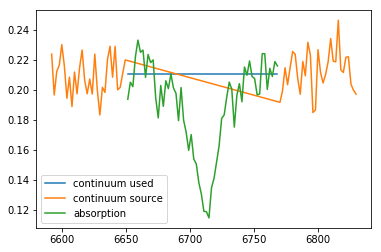

abs_energy/abs_energy_noise: 118.723562111
abs_energy 22.6596510205 +/- 0.19086060608
energy_dif 2.41781501476 +/- 0.457092542863
EW: 11.4681356677 +/- 2.16807293454

=====



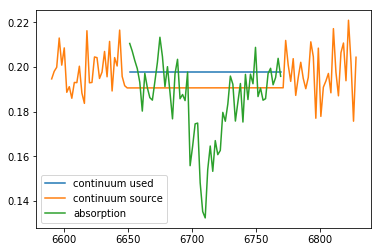

abs_energy/abs_energy_noise: 161.929124731
abs_energy 22.1793449148 +/- 0.136969460877
energy_dif 1.53786342011 +/- 0.412685192943
EW: 7.76919541725 +/- 2.08486128732

=====



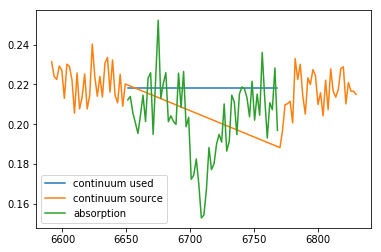

abs_energy/abs_energy_noise: 137.534734512
abs_energy 24.1769033964 +/- 0.175787618177
energy_dif 1.80281647575 +/- 0.464428791691
EW: 8.25354704994 +/- 2.12622024212


(8.2535470499369712, 2.1262202421210046)

In [12]:
spt.get_ew(M0703_file, li_bounds, plot_all=True, cont_width=60)
spt.get_ew(M0729_file, li_bounds, plot_all=True, cont_width=60)
spt.get_ew(M0825_file, li_bounds, plot_all=True, cont_width=60)


=====



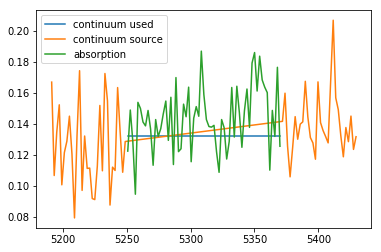

abs_energy/abs_energy_noise: 59.3257780818
abs_energy 17.4246090438 +/- 0.293710585974
energy_dif -1.34563183674 +/- 0.399020246726
EW: -10.150707496 +/- 3.00998958176

=====



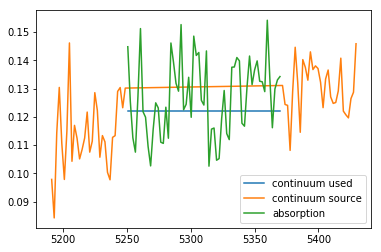

abs_energy/abs_energy_noise: 91.3787051088
abs_energy 15.4145425443 +/- 0.168688563992
energy_dif -0.612281472831 +/- 0.298431123887
EW: -5.01670691835 +/- 2.44518501749

=====



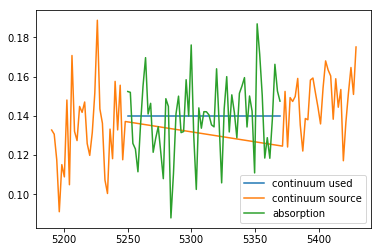

abs_energy/abs_energy_noise: 63.6528291365
abs_energy 16.9253288349 +/- 0.265900653035
energy_dif 0.0796054004044 +/- 0.388851736092
EW: 0.568712725901 +/- 2.77801417593


(0.56871272590070365, 2.7780141759323578)

In [13]:
control_bounds= [5250,5370]
spt.get_ew(M0703_file, control_bounds, plot_all=True, cont_width=60)
spt.get_ew(M0729_file, control_bounds, plot_all=True, cont_width=60)
spt.get_ew(M0825_file, control_bounds, plot_all=True, cont_width=60)


=====



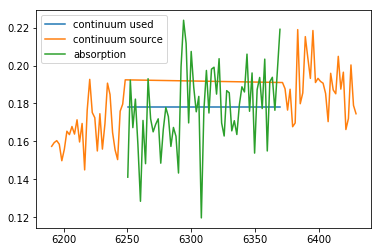

abs_energy/abs_energy_noise: 87.1974973284
abs_energy 21.5543845248 +/- 0.247190403224
energy_dif 0.00369646762706 +/- 0.435031676767
EW: 0.0207650683731 +/- 2.44380944835

=====



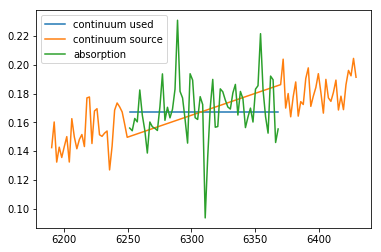

abs_energy/abs_energy_noise: 92.5683271451
abs_energy 20.0511074203 +/- 0.216608726102
energy_dif -0.232153538328 +/- 0.392276130518
EW: -1.38649339284 +/- 2.34279549237

=====



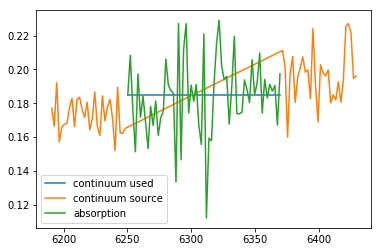

abs_energy/abs_energy_noise: 82.281870159
abs_energy 22.2753944789 +/- 0.270720566217
energy_dif 0.0910094807512 +/- 0.459600265541
EW: 0.492719000322 +/- 2.48824387872


(0.49271900032181826, 2.4882438787213559)

In [14]:
control_bounds= [6250,6370]
spt.get_ew(M0703_file, control_bounds, plot_all=True, cont_width=60)
spt.get_ew(M0729_file, control_bounds, plot_all=True, cont_width=60)
spt.get_ew(M0825_file, control_bounds, plot_all=True, cont_width=60)

In [15]:
test_dist=np.random.normal(size=1000)
og_std= np.std(test_dist)
print(og_std)

0.975373806648


In [16]:
upscaled_test_dist= test_dist*1000
upscaled_std= np.std(upscaled_test_dist)

In [17]:
print(upscaled_std)

975.373806648


So, it would appear that if one rescales a distribution of values, which is what the conversion to energy should qualify as, the error should be scaled by the exact same value, which makes sense since the signal-to-noise should not be affected by conversion of units as I had expected. However, let's see what happens when we simulate a sum of these quantities

In [18]:
summed_test= 10
summed_test_std= np.sqrt(og_std**2*10)
summed_upscaled_test= 1000*10
summed_upscaled_std= np.sqrt(upscaled_std**2*10)
print(summed_test_std)
print(summed_upscaled_std)
print(summed_test/summed_test_std, summed_upscaled_test/summed_upscaled_std)

3.08440279908
3084.40279908
3.2421187022 3.2421187022


So that would suggest that converting the sigma value prior to doing the squared combination is the correct route to take. However, as far as I can tell, that is precisely what I did in my EW calculations...

In [19]:
summed_version= np.zeros(test_dist.shape)
for j in range(0,10):
    summed_version=summed_version+np.random.normal(loc=10,size=1000)
    
print(np.mean(summed_version))
print(np.std(summed_version))
print(np.mean(summed_version)/np.std(summed_version))

99.8947029097
3.23592291674
30.8705446576


In [20]:
np.sqrt(10)

3.1622776601683795


=====



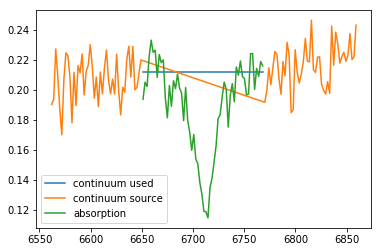

abs_energy/abs_energy_noise: 118.723562111
abs_energy 22.6596510205 +/- 0.19086060608
energy_dif 2.52462451303 +/- 0.391384125679
EW: 11.9239661685 +/- 1.84853274195

=====



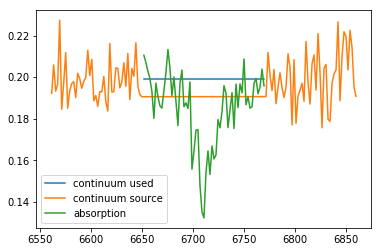

abs_energy/abs_energy_noise: 161.929124731
abs_energy 22.1793449148 +/- 0.136969460877
energy_dif 1.66384820968 +/- 0.346953452212
EW: 8.36124856117 +/- 1.74352686515

=====



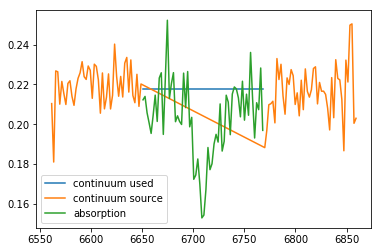

abs_energy/abs_energy_noise: 137.534734512
abs_energy 24.1769033964 +/- 0.175787618177
energy_dif 1.73258515728 +/- 0.392701877384
EW: 7.95351906198 +/- 1.80271766402


(7.953519061984279, 1.8027176640177396)

In [21]:
spt.get_ew(M0703_file, li_bounds, plot_all=True, cont_width=90)
spt.get_ew(M0729_file, li_bounds, plot_all=True, cont_width=90)
spt.get_ew(M0825_file, li_bounds, plot_all=True, cont_width=90)

So I've realized that it's also probably pretty important to do the equivalent width measurement on the model spectrum to verify that it's actually the right amount of lithium abundance since the model absorption looks pretty bad to me at least, and given that it wasn't a requirement to have the continuum-ish portion actually be good there, it's possible that the abundance is overestimated.

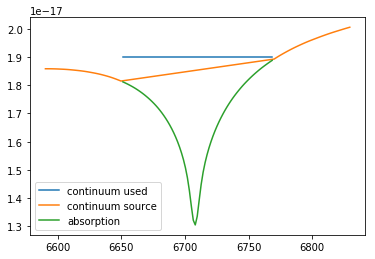

abs_energy/abs_energy_noise: 1.48818791563e-06
abs_energy 2.0178719647e-15 +/- 1.35592551418e-09
energy_dif 2.43234151434e-16 +/- 1.35592551418e-09
EW: 12.7990451802 +/- 71349158.0629


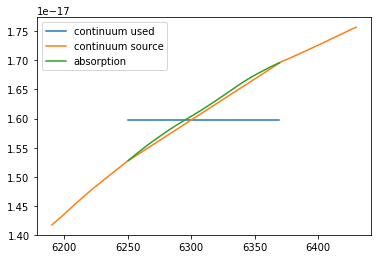

abs_energy/abs_energy_noise: 1.47329013589e-06
abs_energy 1.9503156396e-15 +/- 1.32378245947e-09
energy_dif -2.28363542747e-17 +/- 1.32378245947e-09
EW: -1.42884250248 +/- 82827434.685


(-1.4288425024831488, 82827434.685046956)

In [22]:
spt.get_generic_ew(model_spec, li_bounds, plot_all=True, cont_width=60)
spt.get_generic_ew(model_spec, control_bounds, plot_all=True, cont_width=60)



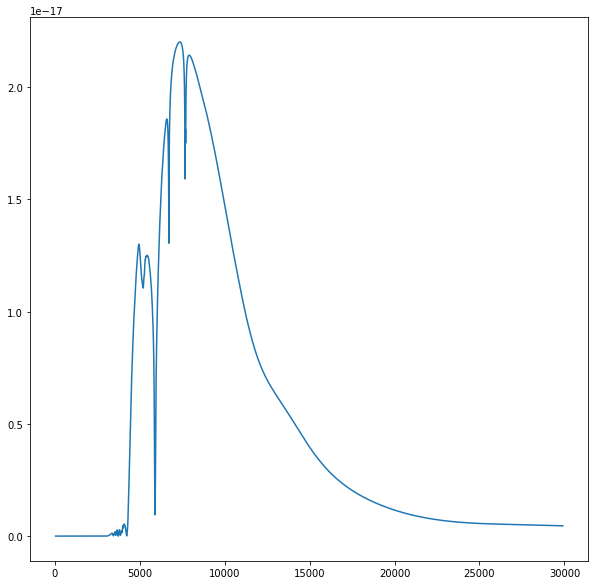

In [25]:
plt.figure(figsize=(10,10))
plt.plot(model_spec[0],model_spec[1])
plt.show()

In [27]:
inbounds= np.where((model_spec[0]>3000)& (model_spec[0]<10000))

In [32]:
inmodel=model_spec[:,inbounds]
inmodel=inmodel[:,0,:]

In [33]:
print(inmodel.shape)

(2, 4124)


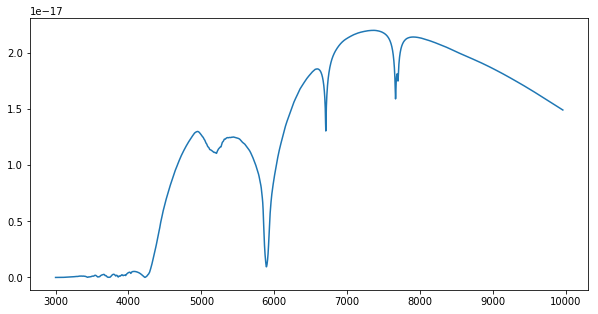

In [35]:
plt.figure(figsize=(10,5))
plt.plot(inmodel[0],inmodel[1])
plt.show()